# CS 61A (Fall 2025) Ants Project Academic Integrity

## Setup

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


import sqlite3
import json

In [2]:
# Connect to the database
DB_PATH = "../../data/private/out/cs61a/fa25/snapshots.db"
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

## How many students are there with Ants backups?

In [3]:
cursor.execute("SELECT COUNT(DISTINCT student_email) FROM backup_metadata")
num_students = cursor.fetchone()[0]
num_students

1185

## How many backups are there total?

In [4]:
cursor.execute("SELECT COUNT(*) FROM backup_metadata")
num_backups_total = cursor.fetchone()[0]
num_backups_total

94183

## How many backups are there per student?

In [5]:
cursor.execute("SELECT COUNT(*) FROM backup_metadata GROUP BY student_email")
num_backups_per_student = np.array([row[0] for row in cursor.fetchall()])

In [6]:
np.min(num_backups_per_student)

np.int64(1)

In [7]:
np.mean(num_backups_per_student)

np.float64(79.47932489451476)

In [8]:
np.median(num_backups_per_student)

np.float64(74.0)

In [9]:
# NOTE: When retrieving backups, we set a limit of 150 backups,
# so there is likely a ceiling effect here
np.max(num_backups_per_student)

np.int64(150)

<Axes: ylabel='Count'>

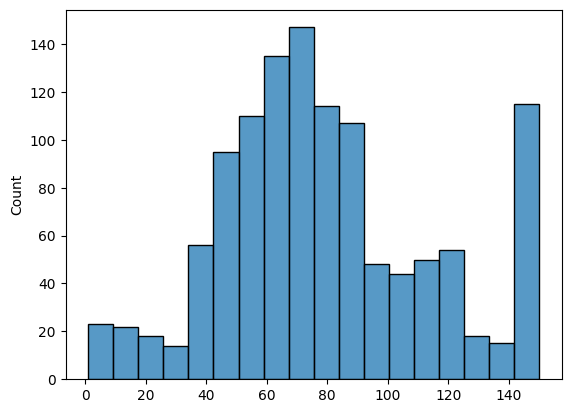

In [10]:
sns.histplot(num_backups_per_student)

## When did students start/finish the assignment? (first backup timestamp vs. last backup timestamp)

In [11]:
cursor.execute("""
    SELECT MIN(created) AS first_created
    FROM backup_metadata
    GROUP BY student_email
""")
first_backup_dates = np.array([row[0] for row in cursor.fetchall()]).astype(
    "datetime64[s]"
)

In [12]:
cursor.execute("""
    SELECT MAX(created) AS first_created
    FROM backup_metadata
    GROUP BY student_email
""")
last_backup_dates = np.array([row[0] for row in cursor.fetchall()]).astype(
    "datetime64[s]"
)

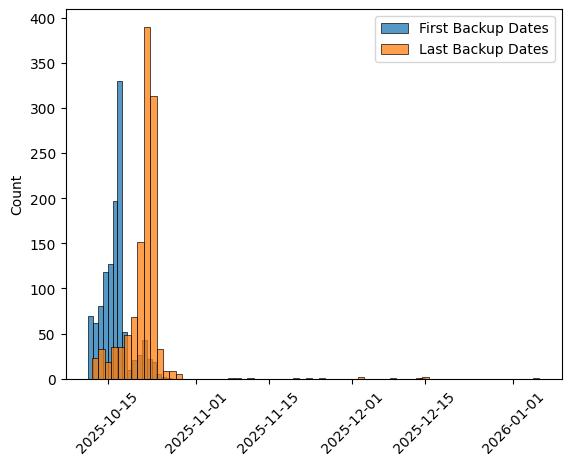

In [13]:
sns.histplot(first_backup_dates, label="First Backup Dates")
sns.histplot(last_backup_dates, label="Last Backup Dates")
plt.xticks(rotation=45)
plt.legend()

In FA25, Ants was released 10/10, Checkpoint 1 due 10/16, Checkpoint 2 due 10/21, EC due date 10/22, and entire project due 10/23. To make the histogram easier to interpret, we exclude students who ended after 10/31.

> The project is worth 25 points. 23 points are for correctness, 1 point(s) for submitting Phase 1 by the first checkpoint date Thursday 10/16, and 1 point(s) for submitting Phase 1 and Phase 2 by the second checkpoint date Tuesday 10/21.
> 
> You can get 1 EC point for submitting the entire project by Wednesday 10/22.

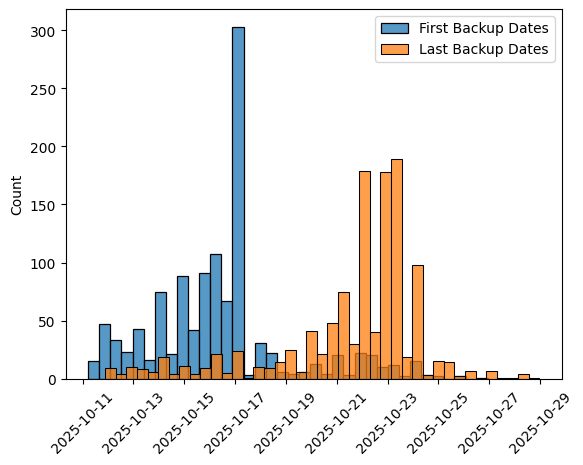

In [14]:
mask = last_backup_dates <= np.datetime64("2025-10-31")
sns.histplot(first_backup_dates[mask], label="First Backup Dates")
sns.histplot(last_backup_dates[mask], label="Last Backup Dates")
plt.xticks(rotation=45)
plt.legend()

## What is the total time spent on the assignment (last backup timestamp - first backup timestamp)

In [15]:
cursor.execute("""
    SELECT
        student_email,
        MIN(created) AS first_created,
        MAX(created) AS last_created,
        (julianday(MAX(created)) - julianday(MIN(created))) * 24 * 60 * 60 as diff_seconds
    FROM backup_metadata
    GROUP BY student_email
""")
total_duration_sec = np.array([row[3] for row in cursor.fetchall()])

Note: We convert back to total duration in days for better interpretability here

In [16]:
total_duration_days = total_duration_sec / (24 * 60 * 60)

In [17]:
np.min(total_duration_days)

np.float64(0.0)

In [18]:
np.mean(total_duration_days)

np.float64(5.576679227224508)

In [19]:
np.median(total_duration_days)

np.float64(5.961215277668089)

In [20]:
np.max(total_duration_days)

np.float64(81.83474537031725)

<Axes: ylabel='Count'>

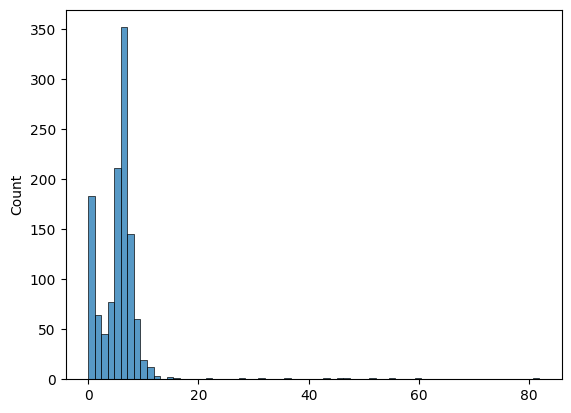

In [21]:
sns.histplot(total_duration_days)

Examine the histogram eliminating outliers. From eyeballing, most students took 20 days or less to do the assignment.

<Axes: ylabel='Count'>

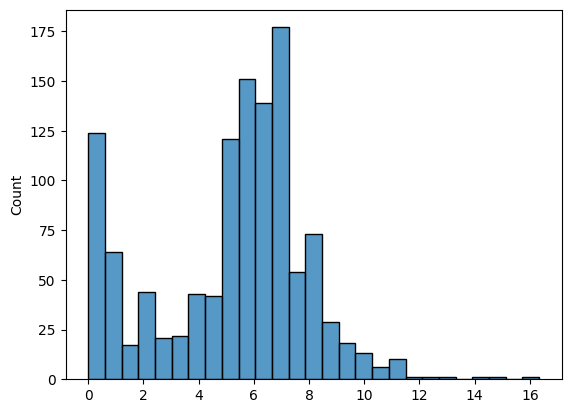

In [22]:
sns.histplot(total_duration_days[total_duration_days <= 20])

## How many problems did students solve by their last backup?

In [23]:
cursor.execute("""
WITH last_backups AS (
    SELECT
        student_email,
        backup_id,
        MAX(created) AS last_created
    FROM backup_metadata
    GROUP BY student_email
)

SELECT
    lb.*,
    history
FROM analytics_messages AS am
JOIN last_backups AS lb
ON am.backup_id = lb.backup_id
""")
last_backup_analytics_histories = [json.loads(row[3]) for row in cursor.fetchall()]
last_backup_analytics_histories[0]

[{'display_name': 'Problem 0', 'attempts': 1, 'solved': True},
 {'display_name': 'Problem 1', 'attempts': 3, 'solved': True},
 {'display_name': 'Problem 2', 'attempts': 1, 'solved': True},
 {'display_name': 'Problem 3', 'attempts': 4, 'solved': False},
 {'display_name': 'Problem 4', 'attempts': 3, 'solved': False},
 {'display_name': 'Problem 5', 'attempts': 1, 'solved': False},
 {'display_name': 'Problem 6', 'attempts': 1, 'solved': False},
 {'display_name': 'Problem 7', 'attempts': 1, 'solved': False},
 {'display_name': 'Problem 8a', 'attempts': 1, 'solved': False},
 {'display_name': 'Problem 8b', 'attempts': 1, 'solved': False},
 {'display_name': 'Problem 8c', 'attempts': 1, 'solved': False},
 {'display_name': 'Problem 9', 'attempts': 1, 'solved': False},
 {'display_name': 'Problem 10', 'attempts': 1, 'solved': False},
 {'display_name': 'Problem 11', 'attempts': 1, 'solved': False},
 {'display_name': 'Problem 12', 'attempts': 1, 'solved': False}]

In [24]:
def count_problems_solved(history: list[dict]) -> int:
    solved = 0
    for problem in history:
        if problem["solved"]:
            solved += 1
    return solved

In [25]:
last_backup_problems_solved = np.array(
    list(map(count_problems_solved, last_backup_analytics_histories))
)
last_backup_problems_solved[0]

np.int64(3)

It looks like this semester students attempted to do the optional problems (standard set contains 15 problems. There are 4 optional problems.)

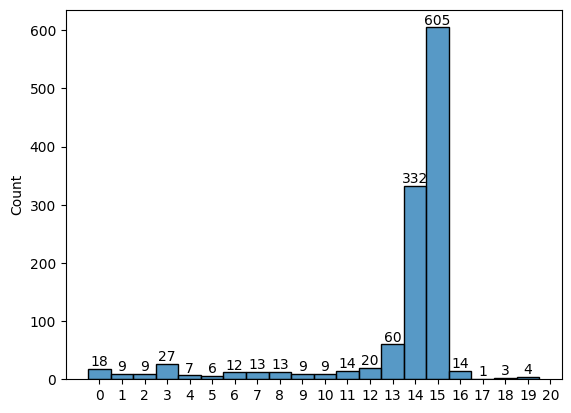

In [26]:
ax = sns.histplot(last_backup_problems_solved, discrete=True)
# Display counts at the top of each bar
ax.bar_label(ax.containers[0])
# Force xticks to be every 1 unit
ax.set_xticks(
    range(
        int(min(last_backup_problems_solved)), int(max(last_backup_problems_solved)) + 2
    )
)
plt.show()

## How many students did autograder spam, defined as >= 20 backups where each consecutive backup is < 5 min apart?

In [27]:
cursor.execute("""
WITH gaps AS (
    SELECT
        student_email,
        -- need this column so that we can create windows ordered by `created` column in CTE below
        created,
        -- Calculate the gap between current and previous
        (julianday(created) - LAG(julianday(created)) OVER (PARTITION BY student_email ORDER BY created)) * 24 * 60 AS gap_minutes
    FROM backup_metadata
),

groups_of_ten AS (
    SELECT
        student_email,
        MAX(gap_minutes) OVER w AS max_gap_in_window,
        -- window may be less than 10, e.g. if processing 1st row
        -- so we have to check the count later
        COUNT(*) OVER w AS num_backups
    FROM gaps
    WINDOW w AS (
        PARTITION BY student_email
        ORDER BY created
        ROWS BETWEEN 20 - 1 PRECEDING AND CURRENT ROW
    )
)

SELECT DISTINCT student_email
FROM groups_of_ten
WHERE max_gap_in_window <= 5 AND num_backups = 20
""")
len(cursor.fetchall())

395

## Lint Errors

- What are the most common lint errors for final backup for each student?
- Which errors were actually caused by the student rather than the starter code?
- How many lint errors on average per student?

In [28]:
cursor.execute(
    "SELECT code, COUNT(*), url FROM lint_errors GROUP BY code ORDER BY COUNT(*) DESC"
)
lint_error_counts_by_code = cursor.fetchall()
lint_error_counts_by_code

[('F401', 274961, 'https://docs.astral.sh/ruff/rules/unused-import'),
 ('E711', 61975, 'https://docs.astral.sh/ruff/rules/none-comparison'),
 ('E712', 27740, 'https://docs.astral.sh/ruff/rules/true-false-comparison'),
 ('invalid-syntax', 15728, None),
 ('F821', 9643, 'https://docs.astral.sh/ruff/rules/undefined-name'),
 ('E701',
  6297,
  'https://docs.astral.sh/ruff/rules/multiple-statements-on-one-line-colon'),
 ('F841', 5910, 'https://docs.astral.sh/ruff/rules/unused-variable'),
 ('F811', 3683, 'https://docs.astral.sh/ruff/rules/redefined-while-unused'),
 ('E703', 2690, 'https://docs.astral.sh/ruff/rules/useless-semicolon'),
 ('E721', 2430, 'https://docs.astral.sh/ruff/rules/type-comparison'),
 ('E702',
  1278,
  'https://docs.astral.sh/ruff/rules/multiple-statements-on-one-line-semicolon'),
 ('E714', 1221, 'https://docs.astral.sh/ruff/rules/not-is-test'),
 ('F541',
  816,
  'https://docs.astral.sh/ruff/rules/f-string-missing-placeholders'),
 ('E741', 695, 'https://docs.astral.sh/ru

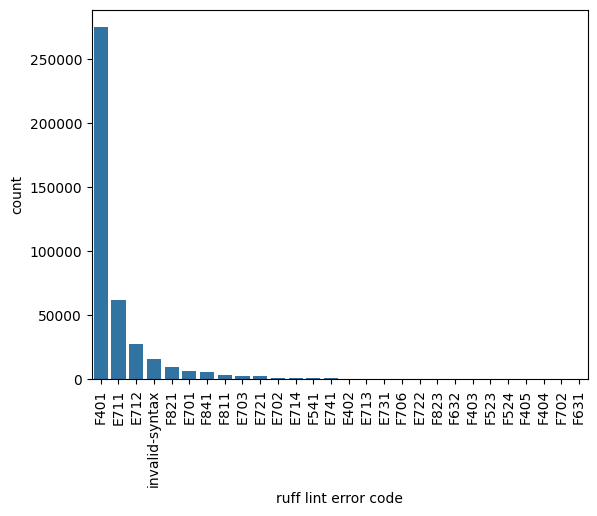

In [29]:
lint_error_codes = [row[0] for row in lint_error_counts_by_code]
lint_error_counts = [row[1] for row in lint_error_counts_by_code]
sns.barplot(x=lint_error_codes, y=lint_error_counts)
plt.xticks(rotation=90)
plt.xlabel("ruff lint error code")
plt.ylabel("count")
plt.show()

In [30]:
cursor.execute("SELECT message FROM lint_errors WHERE code = 'F401' GROUP BY message")
cursor.fetchall()

[('`cats.cats.check_words_and_times` imported but unused',),
 ('`collections.OrderedDict` imported but unused',),
 ('`datetime` imported but unused',),
 ('`functools.reduce` imported but unused',),
 ('`gui.play_laser_beam` imported but unused',),
 ('`gui.reduce_health_decorator` imported but unused',),
 ('`http.cookiejar.uppercase_escaped_char` imported but unused',),
 ('`libs.flask_package.importlib_metadata.distribution` imported but unused',),
 ('`numpy.place` imported but unused',),
 ('`prompt_toolkit.key_binding.bindings.completion.display_completions_like_readline` imported but unused',),
 ('`random` imported but unused',),
 ('`randomfir` imported but unused',),
 ('`re.L` imported but unused',),
 ('`symtable.Class` imported but unused',),
 ('`typing.Container` imported but unused',),
 ('`ucb.interact` imported but unused',),
 ('`ucb.main` imported but unused',),
 ('`ucb.trace` imported but unused',)]

Since F401 is unused import which is often caused by the starter code, let's eliminate that from the analysis. (There were some students who seem to have done accidental imports that were unused, perhaps because of autocomplete or GenAI usage.)

In [31]:
lint_error_counts_by_code.pop(0)

('F401', 274961, 'https://docs.astral.sh/ruff/rules/unused-import')

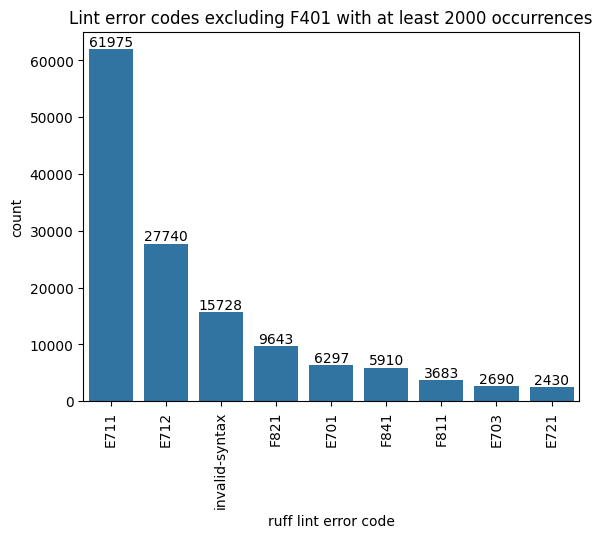

In [32]:
lint_error_codes = [row[0] for row in lint_error_counts_by_code if row[1] >= 2000]
lint_error_counts = [row[1] for row in lint_error_counts_by_code if row[1] >= 2000]
ax = sns.barplot(x=lint_error_codes, y=lint_error_counts)
# Display counts at the top of each bar
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.xlabel("ruff lint error code")
plt.ylabel("count")
plt.title("Lint error codes excluding F401 with at least 2000 occurrences")
plt.show()

We can see that the lint errors with at least 2000 occurrences are:

1. [E711](https://docs.astral.sh/ruff/rules/none-comparison): none comparison
2. [E712](https://docs.astral.sh/ruff/rules/true-false-comparison): true false comparison
3. invalid-syntax (could have many causes, see below). This is perhaps unexpected because I ran the linter on ALL backups including in-progress work
4. [F821](https://docs.astral.sh/ruff/rules/undefined-name): undefined name
5. [E701](https://docs.astral.sh/ruff/rules/multiple-statements-on-one-line-colon/): multiple-statements-on-one-line-colon
6. [F841](https://docs.astral.sh/ruff/rules/unused-variable): unused variable
7. [F811](https://docs.astral.sh/ruff/rules/redefined-while-unused): redefined while unused
8. [E703](useless-semicolon): useless-semicolon
9. [E721](https://docs.astral.sh/ruff/rules/type-comparison/): type-comparison

#3, #5, #8 could be suspicious

In [33]:
cursor.execute("""
SELECT message, COUNT(*)
FROM lint_errors
WHERE code = 'invalid-syntax'
GROUP BY message
-- HAVING COUNT(*) >= 20
ORDER BY COUNT(*) DESC
""")
cursor.fetchall()

[('Simple statements must be separated by newlines or semicolons', 4601),
 ('Expected `,`, found name', 3293),
 ('Expected a statement', 1511),
 ('Expected an expression', 750),
 ('Unexpected indentation', 678),
 ('Expected `:`, found newline', 504),
 ('Compound statements are not allowed on the same line as simple statements',
  403),
 ('Expected an identifier', 397),
 ('Expected an indented block after function definition', 296),
 ('Expected an indented block after `if` statement', 288),
 ('unindent does not match any outer indentation level', 262),
 ('Invalid annotated assignment target', 176),
 ('Expected `:`, found name', 175),
 ('Expected an indented block after `class` definition', 150),
 ('Expected dedent, found end of file', 133),
 ('Invalid decimal integer literal', 110),
 ('Expected `:`, found `=`', 90),
 ('missing closing quote in string literal', 80),
 ('Got unexpected token ️', 80),
 ('Expected `,`, found `:`', 79),
 ('Expected an indented block after `with` statement', 7

**Anything that starts with "Got unexpected token" especially emojis or unicode characters (e.g. [non breaking spaces](https://www.compart.com/en/unicode/U+FEFF) or [zero-width characters](https://www.compart.com/en/unicode/U+200D)) is highly suspect for AI usage.**

In [34]:
cursor.execute("""
SELECT message, COUNT(*)
FROM lint_errors
WHERE code = 'invalid-syntax' AND message LIKE 'Got unexpected token%'
GROUP BY message
ORDER BY COUNT(*) DESC
""")
cursor.fetchall()

[('Got unexpected token ️', 80),
 ('Got unexpected token ✂', 74),
 ('Got unexpected token ’', 52),
 ('Got unexpected token ✅', 20),
 ('Got unexpected token `', 19),
 ('Got unexpected token ?', 17),
 ('Got unexpected token 💻', 16),
 ('Got unexpected token —', 16),
 ('Got unexpected token \u200d', 16),
 ('Got unexpected token –', 14),
 ('Got unexpected token 🧩', 8),
 ('Got unexpected token 👩', 8),
 ('Got unexpected token 👨', 8),
 ('Got unexpected token 🏿', 8),
 ('Got unexpected token 🏽', 8),
 ('Got unexpected token →', 6),
 ('Got unexpected token 🧱', 4),
 ('Got unexpected token “', 4),
 ('Got unexpected token ，', 3),
 ('Got unexpected token ›', 3),
 ('Got unexpected token »', 3),
 ('Got unexpected token 🪲', 2),
 ('Got unexpected token 🧰', 2),
 ('Got unexpected token 🧠', 2),
 ('Got unexpected token 🛡', 2),
 ('Got unexpected token 🔥', 2),
 ('Got unexpected token 🔍', 2),
 ('Got unexpected token 🍽', 2),
 ('Got unexpected token \ufeff', 2),
 ('Got unexpected token ⚙', 2),
 ('Got unexpected to

**Observed this for DATA C88C FA25: a different unicode non-breaking space character**

`Got unexpected token \xa0` is a really strange error that I would not have expected from the Ants project. `\xa0` is the unicode encoding for a [non-breaking space](https://en.wikipedia.org/wiki/Non-breaking_space), which might occur if students were copying and pasting from an HTML source because it does not occur in the Ants starter code as far as I know. (`nbsp` occurs in some of the [auxiliary Ants files](https://github.com/search?q=repo%3ACal-CS-61A-Staff%2Fberkeley-cs61a+%22nbsp%22&type=code) like the debugger (?) that I don't think I've used before...)

**Any unused imports of unauthorized libraries is also suspect.**

In [35]:
cursor.execute("""
SELECT message, COUNT(*)
FROM lint_errors
WHERE code = 'F401'
GROUP BY message
ORDER BY COUNT(*) DESC
""")
cursor.fetchall()

[('`ucb.main` imported but unused', 91555),
 ('`ucb.trace` imported but unused', 91551),
 ('`ucb.interact` imported but unused', 91488),
 ('`datetime` imported but unused', 89),
 ('`http.cookiejar.uppercase_escaped_char` imported but unused', 86),
 ('`typing.Container` imported but unused', 53),
 ('`symtable.Class` imported but unused', 48),
 ('`functools.reduce` imported but unused', 25),
 ('`collections.OrderedDict` imported but unused', 20),
 ('`numpy.place` imported but unused', 15),
 ('`gui.play_laser_beam` imported but unused', 8),
 ('`re.L` imported but unused', 7),
 ('`libs.flask_package.importlib_metadata.distribution` imported but unused',
  6),
 ('`randomfir` imported but unused', 3),
 ('`random` imported but unused', 3),
 ('`prompt_toolkit.key_binding.bindings.completion.display_completions_like_readline` imported but unused',
  2),
 ('`gui.reduce_health_decorator` imported but unused', 1),
 ('`cats.cats.check_words_and_times` imported but unused', 1)]

In [37]:
# create indexes for faster joins
cursor.execute(
    "CREATE INDEX IF NOT EXISTS idx_metadata_email_created ON backup_metadata(student_email, created DESC);"
)
cursor.execute("CREATE INDEX IF NOT EXISTS idx_lint_location ON lint_errors(file_contents_location);")

In [38]:
# Number of lint errors per student on their final backup, excluding F401
cursor.execute("""
WITH last_backups AS (
    SELECT
        backup_id,
        MAX(created) AS created, -- in SQLite this works
        student_email,
        file_contents_location
    FROM backup_metadata
    GROUP BY student_email
),

backups_with_lint_errors AS (
    SELECT
        lb.backup_id,
        lb.created,
        lb.student_email,
        le.*
    FROM last_backups AS lb
    JOIN lint_errors AS le
    ON REPLACE(lb.file_contents_location, '../../data/private/', '') = REPLACE(le.file_contents_location, '/ants.py', '')
    WHERE le.code != 'F401'
)

SELECT
    student_email,
    COUNT(*)
FROM backups_with_lint_errors
GROUP BY student_email
ORDER BY COUNT(*) DESC
""")
student_to_lint_error_count = cursor.fetchall()
student_to_lint_error_count

[('7c0e71aa', 64),
 ('a9ed94c4', 25),
 ('a2288276', 21),
 ('3d82d0eb', 19),
 ('8b0c70ca', 18),
 ('543dd025', 18),
 ('220c4d51', 18),
 ('ed93a698', 16),
 ('6846a3fc', 16),
 ('ce726000', 15),
 ('c5ce5d14', 15),
 ('c1ad0973', 15),
 ('68182f7d', 15),
 ('d575c143', 14),
 ('b43ba4ec', 14),
 ('b356348d', 14),
 ('9e40a10a', 14),
 ('8e1e48e6', 14),
 ('4349b29d', 14),
 ('252ad37f', 14),
 ('08a9eac0', 14),
 ('f035e859', 13),
 ('4b98b377', 13),
 ('478503a4', 13),
 ('c4525ba8', 12),
 ('c3fec52c', 12),
 ('b92230f6', 12),
 ('7dce0432', 12),
 ('35b4e77f', 12),
 ('27f16a00', 12),
 ('e3384165', 11),
 ('ddfd7805', 11),
 ('d017bec5', 11),
 ('c2b307c8', 11),
 ('87ad2bbe', 11),
 ('7c1eab53', 11),
 ('55d9e0b2', 11),
 ('2a2a8f09', 11),
 ('2378022b', 11),
 ('20afefcb', 11),
 ('f55123d0', 10),
 ('f0e5c63d', 10),
 ('e565a370', 10),
 ('c73ec56a', 10),
 ('b5ef43d7', 10),
 ('a42c12ba', 10),
 ('8530ff77', 10),
 ('5b6d2ef2', 10),
 ('579ea8a5', 10),
 ('44097c10', 10),
 ('29c6ff8b', 10),
 ('27e033b0', 10),
 ('0792e906'

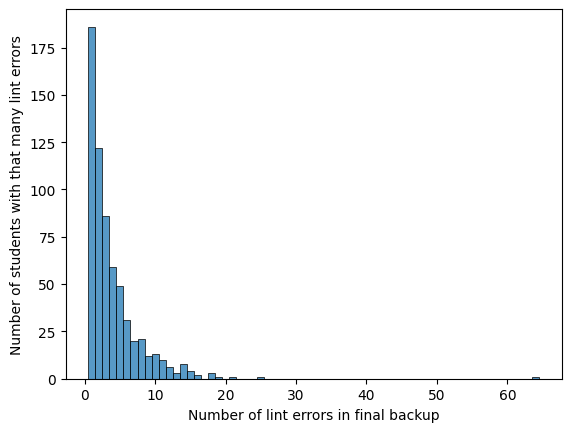

In [39]:
sns.histplot([row[1] for row in student_to_lint_error_count], discrete=True)
plt.xlabel("Number of lint errors in final backup")
plt.ylabel("Number of students with that many lint errors")
plt.show()

In [40]:
# Most common lint errors in final backup
cursor.execute("""
WITH last_backups AS (
    SELECT
        backup_id,
        MAX(created) AS created, -- in SQLite this works
        student_email,
        file_contents_location
    FROM backup_metadata
    GROUP BY student_email
),

backups_with_lint_errors AS (
    SELECT
        lb.backup_id,
        lb.created,
        lb.student_email,
        le.*
    FROM last_backups AS lb
    JOIN lint_errors AS le
    ON REPLACE(lb.file_contents_location, '../../data/private/', '') = REPLACE(le.file_contents_location, '/ants.py', '')
    WHERE le.code != 'F401'
)

SELECT code, COUNT(*)
FROM backups_with_lint_errors
GROUP BY code
ORDER BY COUNT(*) DESC
""")
common_lint_errors_final_backups = cursor.fetchall()
common_lint_errors_final_backups

[('E711', 1292),
 ('E712', 741),
 ('E701', 126),
 ('F811', 68),
 ('E703', 68),
 ('F841', 63),
 ('F821', 31),
 ('E714', 30),
 ('E721', 18),
 ('E402', 15),
 ('E741', 14),
 ('F541', 11),
 ('E702', 11),
 ('E713', 6),
 ('invalid-syntax', 4),
 ('F706', 2),
 ('F403', 2),
 ('E722', 2),
 ('F524', 1),
 ('F523', 1),
 ('F405', 1),
 ('F404', 1),
 ('E731', 1)]

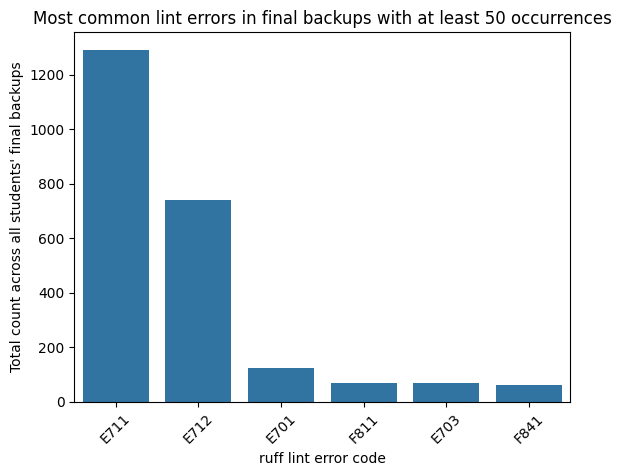

In [41]:
sns.barplot(
    x=[row[0] for row in common_lint_errors_final_backups if row[1] >= 50],
    y=[row[1] for row in common_lint_errors_final_backups if row[1] >= 50],
)
plt.xticks(rotation=45)
plt.xlabel("ruff lint error code")
plt.ylabel("Total count across all students' final backups")
plt.title("Most common lint errors in final backups with at least 50 occurrences")
plt.show()

See links to examples below.

In [42]:
def create_ruff_url(code: str) -> str:
    return f"https://docs.astral.sh/ruff/rules/{code}"


list(map(create_ruff_url, [row[0] for row in common_lint_errors_final_backups if row[1] >= 50]))

['https://docs.astral.sh/ruff/rules/E711',
 'https://docs.astral.sh/ruff/rules/E712',
 'https://docs.astral.sh/ruff/rules/E701',
 'https://docs.astral.sh/ruff/rules/F811',
 'https://docs.astral.sh/ruff/rules/E703',
 'https://docs.astral.sh/ruff/rules/F841']

## Number of lines

In [43]:
cursor.execute("""
WITH backup_line_counts AS (
    SELECT
        m.student_email,
        m.course,
        m.assignment,
        m.created,
        f.file_name,
        f.num_lines
    FROM backup_metadata AS m
    JOIN backup_file_metadata AS f
    ON m.file_contents_location = f.file_contents_location
),

consecutive_changes AS (
    -- Step 2: Use LAG to find the line count of the previous backup
    SELECT
        student_email,
        course,
        assignment,
        created,
        file_name,
        num_lines AS current_lines,
        LAG(num_lines) OVER (
            PARTITION BY student_email, course, assignment, file_name
            ORDER BY created ASC
        ) AS prev_lines
    FROM backup_line_counts
),

-- each row is a student's backup with line diff count
line_diffs AS (
    SELECT
        student_email,
        course,
        assignment,
        file_name,
        created,
        current_lines,
        prev_lines,
        -- for first backup, there is no prev_lines
        (current_lines - IFNULL(prev_lines, current_lines)) AS lines_diff
    FROM consecutive_changes
    ORDER BY student_email, created ASC
)

SELECT
    student_email,
    AVG(lines_diff)
FROM line_diffs
GROUP BY student_email
ORDER BY AVG(lines_diff) DESC, student_email
""")
line_diffs = cursor.fetchall()
line_diffs[:5]

[('a5b841d2', 34.4),
 ('4fd64dba', 13.875),
 ('13bb07b0', 10.375),
 ('cfaf3ebc', 10.181818181818182),
 ('ddec8a37', 10.0)]

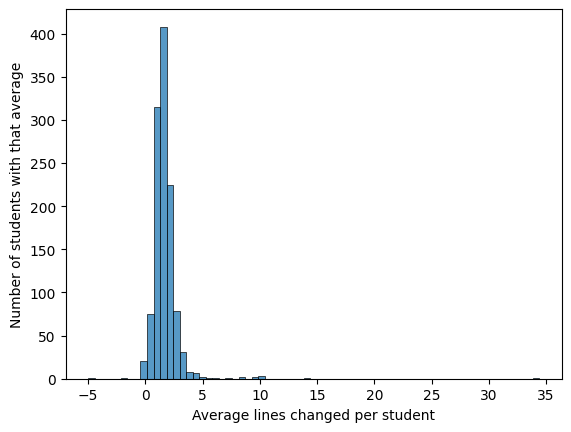

In [44]:
sns.histplot([row[1] for row in line_diffs])
plt.xlabel("Average lines changed per student")
plt.ylabel("Number of students with that average")
plt.show()

In [45]:
np.median(np.array([row[1] for row in line_diffs]))

np.float64(1.513157894736842)

In [46]:
np.std(np.array([row[1] for row in line_diffs]))

np.float64(1.4223395197552782)

In [47]:
np.random.seed(42)

In [48]:
# Choose random student email
random_student_email = str(np.random.choice([row[0] for row in line_diffs]))
random_student_email

'30edfe4f'

In [49]:
# Look at the "journey" of one particular student - when do students make changes?
cursor.execute(f"""
WITH backup_line_counts AS (
    SELECT
        m.student_email,
        m.course,
        m.assignment,
        m.created,
        f.file_name,
        f.num_lines
    FROM backup_metadata AS m
    JOIN backup_file_metadata AS f
    ON m.file_contents_location = f.file_contents_location
),

consecutive_changes AS (
    -- Step 2: Use LAG to find the line count of the previous backup
    SELECT
        student_email,
        course,
        assignment,
        created,
        file_name,
        num_lines AS current_lines,
        LAG(num_lines) OVER (
            PARTITION BY student_email, course, assignment, file_name
            ORDER BY created ASC
        ) AS prev_lines
    FROM backup_line_counts
),

-- each row is a student's backup with line diff count
line_diffs AS (
    SELECT
        student_email,
        course,
        assignment,
        file_name,
        created,
        current_lines,
        prev_lines,
        -- for first backup, there is no prev_lines
        (current_lines - IFNULL(prev_lines, current_lines)) AS lines_diff
    FROM consecutive_changes
    ORDER BY student_email, created ASC
)

SELECT *
FROM line_diffs
WHERE student_email = '{random_student_email}'
ORDER BY created
""")
random_student_line_diffs = cursor.fetchall()
random_student_line_diffs[:5]

[('30edfe4f',
  'cal/cs61a/fa25',
  'ants',
  'ants.py',
  '2025-10-15T06:19:06',
  798,
  None,
  0),
 ('30edfe4f',
  'cal/cs61a/fa25',
  'ants',
  'ants.py',
  '2025-10-15T06:22:27',
  798,
  798,
  0),
 ('30edfe4f',
  'cal/cs61a/fa25',
  'ants',
  'ants.py',
  '2025-10-15T06:24:01',
  796,
  798,
  -2),
 ('30edfe4f',
  'cal/cs61a/fa25',
  'ants',
  'ants.py',
  '2025-10-15T06:33:39',
  796,
  796,
  0),
 ('30edfe4f',
  'cal/cs61a/fa25',
  'ants',
  'ants.py',
  '2025-10-15T06:33:49',
  796,
  796,
  0)]

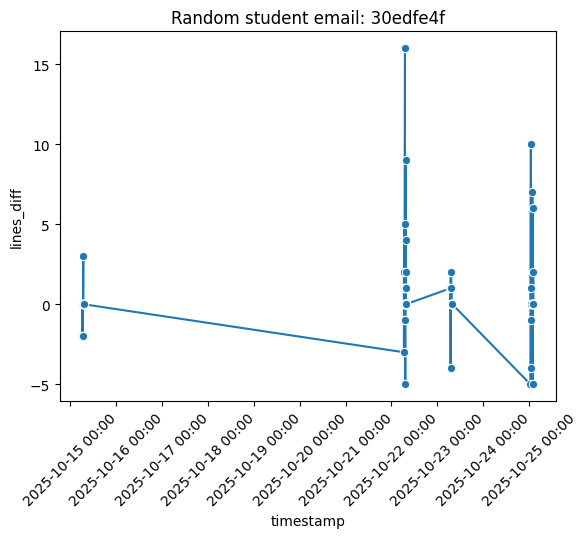

In [50]:
data = {
    "timestamp": [row[4] for row in random_student_line_diffs],
    "lines_diff": [row[7] for row in random_student_line_diffs],
}
df = pd.DataFrame(data)

df["timestamp"] = pd.to_datetime(df["timestamp"])

ax = sns.lineplot(data=df, x="timestamp", y="lines_diff", marker="o")

# Force the same date format in the plot
date_formatter = mdates.DateFormatter("%Y-%m-%d %H:%M")
ax.xaxis.set_major_formatter(date_formatter)

plt.xticks(rotation=45)
plt.title(f"Random student email: {random_student_email}")
plt.show()

## Time between backups

In [51]:
cursor.execute("""
SELECT
    backup_id,
    (
        unixepoch(created) -
        unixepoch(LAG(created) OVER (
            PARTITION BY student_email, course, assignment
            ORDER BY created
        ))
    ) AS duration_between_backups_sec,
    student_email
FROM backup_metadata
ORDER BY student_email, course, assignment, created;
""")
time_between_backups = cursor.fetchall()
time_between_backups[:5]

[('p7P8zN', None, '0007feaa'),
 ('AAxNQP', 198, '0007feaa'),
 ('KmR1YY', 144, '0007feaa'),
 ('0OBY2K', 284, '0007feaa'),
 ('jLPZvl', 12, '0007feaa')]

In [52]:
time_between_backups_df = pd.DataFrame.from_dict(
    {
        "backup_id": [row[0] for row in time_between_backups if row[1] is not None],
        "duration_between_backups_sec": [
            row[1] for row in time_between_backups if row[1] is not None
        ],
        "student_email": [row[2] for row in time_between_backups if row[1] is not None],
    }
)
time_between_backups_df.head()

,backup_id,duration_between_backups_sec,student_email
0,AAxNQP,198,0007feaa
1,KmR1YY,144,0007feaa
2,0OBY2K,284,0007feaa
3,jLPZvl,12,0007feaa
4,lDPxvr,29,0007feaa


In [53]:
time_between_backups_df.shape

(92998, 3)

In [54]:
time_between_backups_df["duration_between_backups_sec"].min()

np.int64(0)

In [55]:
time_between_backups_df["duration_between_backups_sec"].mean()

np.float64(6139.5161831437235)

In [56]:
time_between_backups_df["duration_between_backups_sec"].median()

np.float64(68.0)

In [57]:
time_between_backups_df["duration_between_backups_sec"].max()

np.int64(6555402)

In [58]:
avg_duration_between_backups_sec_per_student = time_between_backups_df.groupby(
    "student_email"
)["duration_between_backups_sec"].mean()

Text(0, 0.5, 'Number of students')

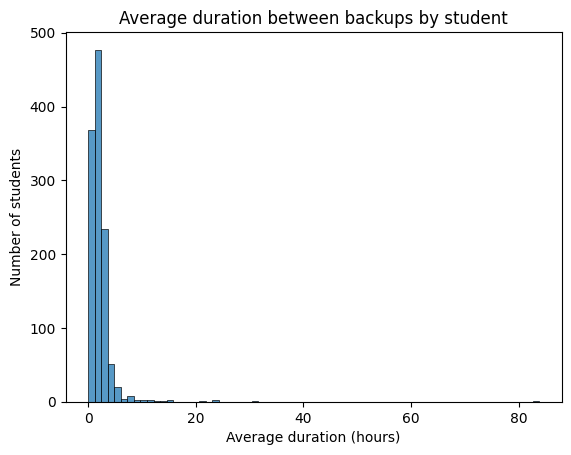

In [59]:
sns.histplot(avg_duration_between_backups_sec_per_student / (60 * 60))
plt.title("Average duration between backups by student")
plt.xlabel("Average duration (hours)")
plt.ylabel("Number of students")

In [60]:
median_duration_between_backups_sec_per_student = time_between_backups_df.groupby(
    "student_email"
)["duration_between_backups_sec"].median()

Text(0, 0.5, 'Number of students')

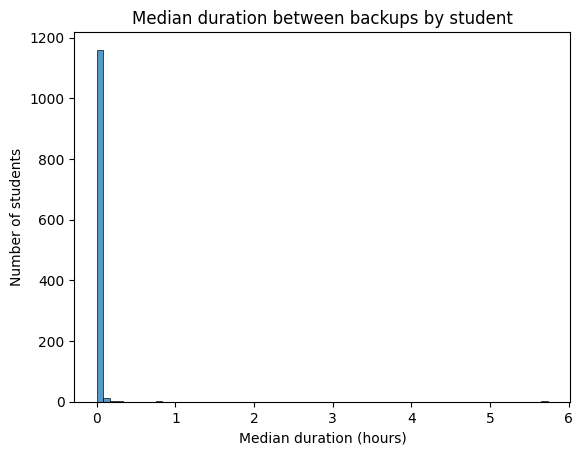

In [61]:
sns.histplot(median_duration_between_backups_sec_per_student / (60 * 60))
plt.title("Median duration between backups by student")
plt.xlabel("Median duration (hours)")
plt.ylabel("Number of students")

## Grouping by problem, type, and worksession

In [62]:
cursor.execute("""
SELECT
    bm.backup_id,
    unixepoch(bm.created),
    bm.course,
    bm.assignment,
    bm.student_email,
    am.unlock,
    am.question_cli_names
FROM backup_metadata AS bm
JOIN analytics_messages AS am
ON bm.backup_id = am.backup_id
ORDER BY bm.student_email, bm.created
""")
backups_with_analytics = cursor.fetchall()
backups_with_analytics[:5]

[('p7P8zN', 1761316585, 'cal/cs61a/fa25', 'ants', '0007feaa', 1, '["00"]'),
 ('AAxNQP', 1761316783, 'cal/cs61a/fa25', 'ants', '0007feaa', 1, '["01"]'),
 ('KmR1YY', 1761316927, 'cal/cs61a/fa25', 'ants', '0007feaa', 0, '["01"]'),
 ('0OBY2K', 1761317211, 'cal/cs61a/fa25', 'ants', '0007feaa', 0, '["01"]'),
 ('jLPZvl', 1761317223, 'cal/cs61a/fa25', 'ants', '0007feaa', 0, '["01"]')]

In [63]:
def group_by_problem_worksession(
    backups_with_analytics, threshold_sec=30 * 60
) -> dict[str, list[list[tuple]]]:
    # TODO currently this code makes the assumption that there's only one course and assignment in the db
    from collections import defaultdict

    result = defaultdict(list)

    prev_student_email = None
    prev_question_cli_names = None
    prev_created = None

    for backup in backups_with_analytics:
        (
            backup_id,
            created,
            course,
            assignment,
            student_email,
            unlock,
            question_cli_names,
        ) = backup
        if (
            (prev_student_email is None or prev_student_email != student_email)
            or (
                prev_question_cli_names is None
                or prev_question_cli_names != question_cli_names
            )
            or (prev_created is None or (created - prev_created > threshold_sec))
        ):
            result[student_email].append([backup])
        else:
            group_index = len(result[student_email]) - 1
            curr_group = result[student_email][group_index]
            curr_group.append(backup)

        prev_student_email = student_email
        prev_question_cli_names = question_cli_names
        prev_created = created

    return result

In [64]:
grouped_backups = group_by_problem_worksession(backups_with_analytics)
grouped_backups["0a34fadf"][:10]

[]

In [65]:
num_groups_total = 0
group_size_total = 0

for student_email, groups in grouped_backups.items():
    num_groups_total += len(groups)

    for g in groups:
        group_size_total += len(g)

print("Average number of groups by student:", num_groups_total / len(grouped_backups))
print("Average group size across all groups:", group_size_total / num_groups_total)

Average number of groups by student: 27.22175379426644
Average group size across all groups: 2.9172371070156418


In [66]:
np.random.seed(42)

In [67]:
from datetime import datetime

random_student_email = np.random.choice(list(grouped_backups.keys()))
# get the created unix epoch timestamp of the first backup in each group, AND group size
random_student_worksessions = [
    (group[0][1], len(group)) for group in grouped_backups[random_student_email]
]
random_student_worksessions = pd.DataFrame.from_dict(
    {
        "created": [
            datetime.fromtimestamp(int(ts)) for ts, _ in random_student_worksessions
        ],
        "group_size": [size for _, size in random_student_worksessions],
    }
)
random_student_worksessions.head()

,created,group_size
0,2025-10-16 11:45:54,1
1,2025-10-16 11:59:02,2
2,2025-10-16 12:12:27,2
3,2025-10-16 12:46:44,8
4,2025-10-16 13:13:06,1


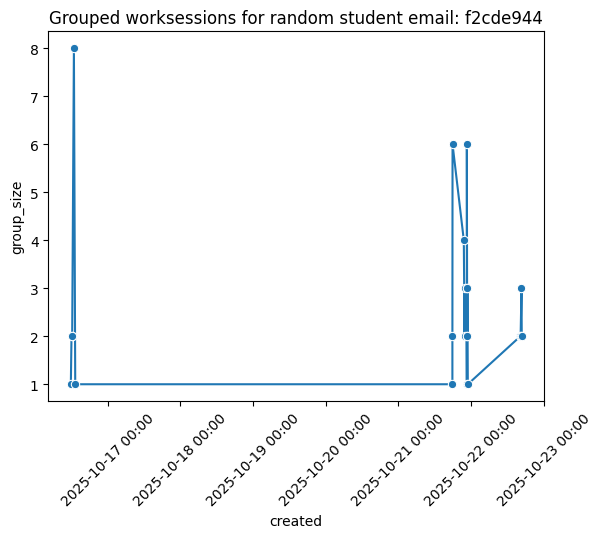

In [68]:
ax = sns.lineplot(
    data=random_student_worksessions, x="created", y="group_size", marker="o"
)

# Force the same date format in the plot
date_formatter = mdates.DateFormatter("%Y-%m-%d %H:%M")
ax.xaxis.set_major_formatter(date_formatter)

plt.xticks(rotation=45)
plt.title(f"Grouped worksessions for random student email: {random_student_email}")
plt.show()

## Teardown

In [69]:
# Close db connection
conn.close()